In [4]:
import torch
import numpy as np
from datasets import load_dataset
from tqdm.auto import tqdm
from torchvision.models import resnet50, ResNet50_Weights
import warnings

In [5]:
def bit2float(b, num_e_bits=8, num_m_bits=23, bias=127.):
    """Turn input tensor into float.

        Args:
            b : binary tensor. The last dimension of this tensor should be the
            the one the binary is at.
            num_e_bits : Number of exponent bits. Default: 8.
            num_m_bits : Number of mantissa bits. Default: 23.
            bias : Exponent bias/ zero offset. Default: 127.
        Returns:
            Tensor: Float tensor. Reduces last dimension.

    """
    expected_last_dim = num_m_bits + num_e_bits + 1
    assert b.shape[-1] == expected_last_dim, "Binary tensors last dimension " \
                                             "should be {}, not {}.".format(
        expected_last_dim, b.shape[-1])

    # check if we got the right type
    dtype = torch.float32
    if expected_last_dim > 32: dtype = torch.float64
    if expected_last_dim > 64:
        warnings.warn("pytorch can not process floats larger than 64 bits, keep"
                      " this in mind. Your result will be not exact.")

    s = torch.index_select(b, -1, torch.arange(0, 1))
    e = torch.index_select(b, -1, torch.arange(1, 1 + num_e_bits))
    m = torch.index_select(b, -1, torch.arange(1 + num_e_bits,
                                               1 + num_e_bits + num_m_bits))
    # SIGN BIT
    out = ((-1) ** s).squeeze(-1).type(dtype)
    # EXPONENT BIT
    exponents = -torch.arange(-(num_e_bits - 1.), 1.)
    exponents = exponents.repeat(b.shape[:-1] + (1,))
    e_decimal = torch.sum(e * 2 ** exponents, dim=-1) - bias
    out *= 2 ** e_decimal
    # MANTISSA
    matissa = (torch.Tensor([2.]) ** (
        -torch.arange(1., num_m_bits + 1.))).repeat(
        m.shape[:-1] + (1,))
    out *= 1. + torch.sum(m * matissa, dim=-1)
    return out


def float2bit(f, num_e_bits=8, num_m_bits=23, bias=127., dtype=torch.float32):
    """Turn input tensor into binary.

        Args:
            f : float tensor.
            num_e_bits : Number of exponent bits. Default: 8.
            num_m_bits : Number of mantissa bits. Default: 23.
            bias : Exponent bias/ zero offset. Default: 127.
            dtype : This is the actual type of the tensor that is going to be
            returned. Default: torch.float32.
        Returns:
            Tensor: Binary tensor. Adds last dimension to original tensor for
            bits.

    """
    ## SIGN BIT
    s = torch.sign(f)
    f = f * s
    # turn sign into sign-bit
    s = (s * (-1) + 1.) * 0.5
    s[s == 0.5] = 1
    s = s.unsqueeze(-1)

    ## EXPONENT BIT
    e_scientific = torch.floor(torch.log2(f))
    e_decimal = e_scientific + bias
    e = integer2bit(e_decimal, num_bits=num_e_bits)
    e[torch.isnan(e)] = 0

    ## MANTISSA
    m1 = integer2bit(f - f % 1, num_bits=num_e_bits)
    m2 = remainder2bit(f % 1, num_bits=bias)
    m = torch.cat([m1, m2], dim=-1)

    dtype = f.type()
    idx = torch.arange(num_m_bits).unsqueeze(0).type(dtype) \
          + (8. - e_scientific).unsqueeze(-1)
    idx = idx.long()
    idx[idx == -9223372036854775808] = 0
    m = torch.gather(m, dim=-1, index=idx)

    return torch.cat([s, e, m], dim=-1).type(dtype)


def remainder2bit(remainder, num_bits=127):
    """Turn a tensor with remainders (floats < 1) to mantissa bits.

        Args:
            remainder : torch.Tensor, tensor with remainders
            num_bits : Number of bits to specify the precision. Default: 127.
        Returns:
            Tensor: Binary tensor. Adds last dimension to original tensor for
            bits.

    """
    dtype = remainder.type()
    exponent_bits = torch.arange(num_bits).type(dtype)
    exponent_bits = exponent_bits.repeat(remainder.shape + (1,))
    out = (remainder.unsqueeze(-1) * 2 ** exponent_bits) % 1
    return torch.floor(2 * out)


def integer2bit(integer, num_bits=8):
    """Turn integer tensor to binary representation.

        Args:
            integer : torch.Tensor, tensor with integers
            num_bits : Number of bits to specify the precision. Default: 8.
        Returns:
            Tensor: Binary tensor. Adds last dimension to original tensor for
            bits.

    """
    dtype = integer.type()
    exponent_bits = -torch.arange(-(num_bits - 1), 1).type(dtype)
    exponent_bits = exponent_bits.repeat(integer.shape + (1,))
    out = integer.unsqueeze(-1) / 2 ** exponent_bits
    return (out - (out % 1)) % 2


In [6]:
def int_tensor_to_binary_with_sign(tensor, binary_length=7):
    # Ensure tensor is a NumPy array
    data_type = np.int8

    tensor = np.array(tensor, dtype=data_type)

    if not isinstance(tensor, np.ndarray):
        raise ValueError("Input must be a NumPy array")

    # Get the shape of the tensor
    shape = tensor.shape

    # Initialize a 3D array to store the binary representation without the sign bit
    binary_tensor = np.zeros(shape + (binary_length,), dtype=data_type)

    # Use bitwise operations to fill the binary_tensor
    for i in range(binary_length):
        binary_tensor[..., binary_length - 1 - i] = (abs(tensor) & (1 << i)) >> i

    # Initialize a 3D array to store the final binary representation with the sign bit
    binary_tensor_with_sign = np.zeros(shape + (binary_length + 1,), dtype=data_type)

    # Add sign bit
    binary_tensor_with_sign[..., 0] = np.where(tensor < 0, 1, 0)

    # Copy the binary representation without the sign bit to the final array
    binary_tensor_with_sign[..., 1:] = binary_tensor

    return binary_tensor_with_sign

def tensor_to_integers(binary_tensor):
    # Extract the sign bit and 7 bits of binary representation
    sign_bit = binary_tensor[..., 0]
    binary_representation = binary_tensor[..., 1:]

    # Convert binary to decimal
    powers_of_two = 2**torch.arange(binary_representation.size(-1) - 1, -1, -1, dtype=binary_representation.dtype)
    decimal_values = torch.sum(binary_representation * powers_of_two, dim=-1)

    # Apply the sign bit
    decimal_values = torch.where(sign_bit == 1, -decimal_values, decimal_values)

    return decimal_values

In [7]:
def add_noise_quantize_layer(prob,mask,layer):
    w = layer
    c_max = w.abs().max().item()

    if c_max > 0:
        step = c_max / float(2 ** (8 - 1) - 1)
        labels = torch.round(w / step)
        pred = int_tensor_to_binary_with_sign(labels)
        pred = torch.tensor(pred)
        shape = pred.shape
        pred = pred.reshape(-1)

        mask_length = pred.numel()
        repeats = mask_length // len(mask)
        duplicated_array = np.tile(mask, repeats)[:mask_length]
        mask = torch.IntTensor(duplicated_array)

        noise_mask = torch.rand(mask_length)
        noise_mask = (noise_mask < prob)

        noise_weight_binary = pred.int() ^ (noise_mask.int() & (~mask))
        noise_weight_binary = noise_weight_binary.to(torch.int8)
        noise_weight_binary = noise_weight_binary.reshape(shape)

        noise_weight = tensor_to_integers(noise_weight_binary)

        w_q = noise_weight * step
        noise_weight = w_q

    return noise_weight

In [8]:
conv_layer_names = [
    'conv1.weight',
    'layer1.0.conv1.weight',
    'layer1.0.conv2.weight',
    'layer1.1.conv1.weight',
    'layer1.1.conv2.weight',
    'layer2.0.conv1.weight',
    'layer2.0.conv2.weight',
    'layer2.0.downsample.0.weight',
    'layer2.1.conv1.weight',
    'layer2.1.conv2.weight',
    'layer3.0.conv1.weight',
    'layer3.0.conv2.weight',
    'layer3.0.downsample.0.weight',
    'layer3.1.conv1.weight',
    'layer3.1.conv2.weight',
    'layer4.0.conv1.weight',
    'layer4.0.conv2.weight',
    'layer4.0.downsample.0.weight',
    'layer4.1.conv1.weight',
    'layer4.1.conv2.weight',
    'fc.weight',
]

In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from copy import deepcopy

prob_list = [1e-10, 5e-10, 1e-9,5e-9, 1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1]

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download CIFAR-10 dataset for evaluation
eval_dataset = datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False, num_workers=4)

# Create ResNet18 model
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)  # Adjust the last layer for 10 classes in CIFAR-10

# Load the pre-trained weights
model_path = 'resnet18_cifar10_epoch_3000.pth'  # Replace with the path to your saved model
model.load_state_dict(torch.load(model_path, map_location=device))

mask = [0,0,0,0,0,0,0,0]

original_dict = model.state_dict()

model = model.to(device)

total_acc = []

epoch = 10

for prob in prob_list:
    avg_acc = 0

    for i in range(0,epoch):

        params = deepcopy(original_dict)

        for layer_name in conv_layer_names:

            layer_weights = params[layer_name]
            noise_weight = add_noise_quantize_layer(prob,mask,layer_weights)
            params[layer_name] = noise_weight

        model.load_state_dict(params)

        # Evaluate the model on the test set
        model.eval()
        correct = 0
        total = 0
        print("start inference")
        with torch.no_grad():
            for inputs, labels in eval_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracy = correct / total
        avg_acc = avg_acc + accuracy
        print(f'Test Accuracy: {accuracy:.4f}')
    total_acc.append(avg_acc/epoch)

print(total_acc)

Files already downloaded and verified


/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7853
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7856
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7852
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start inference
Test Accuracy: 0.7854
start infere

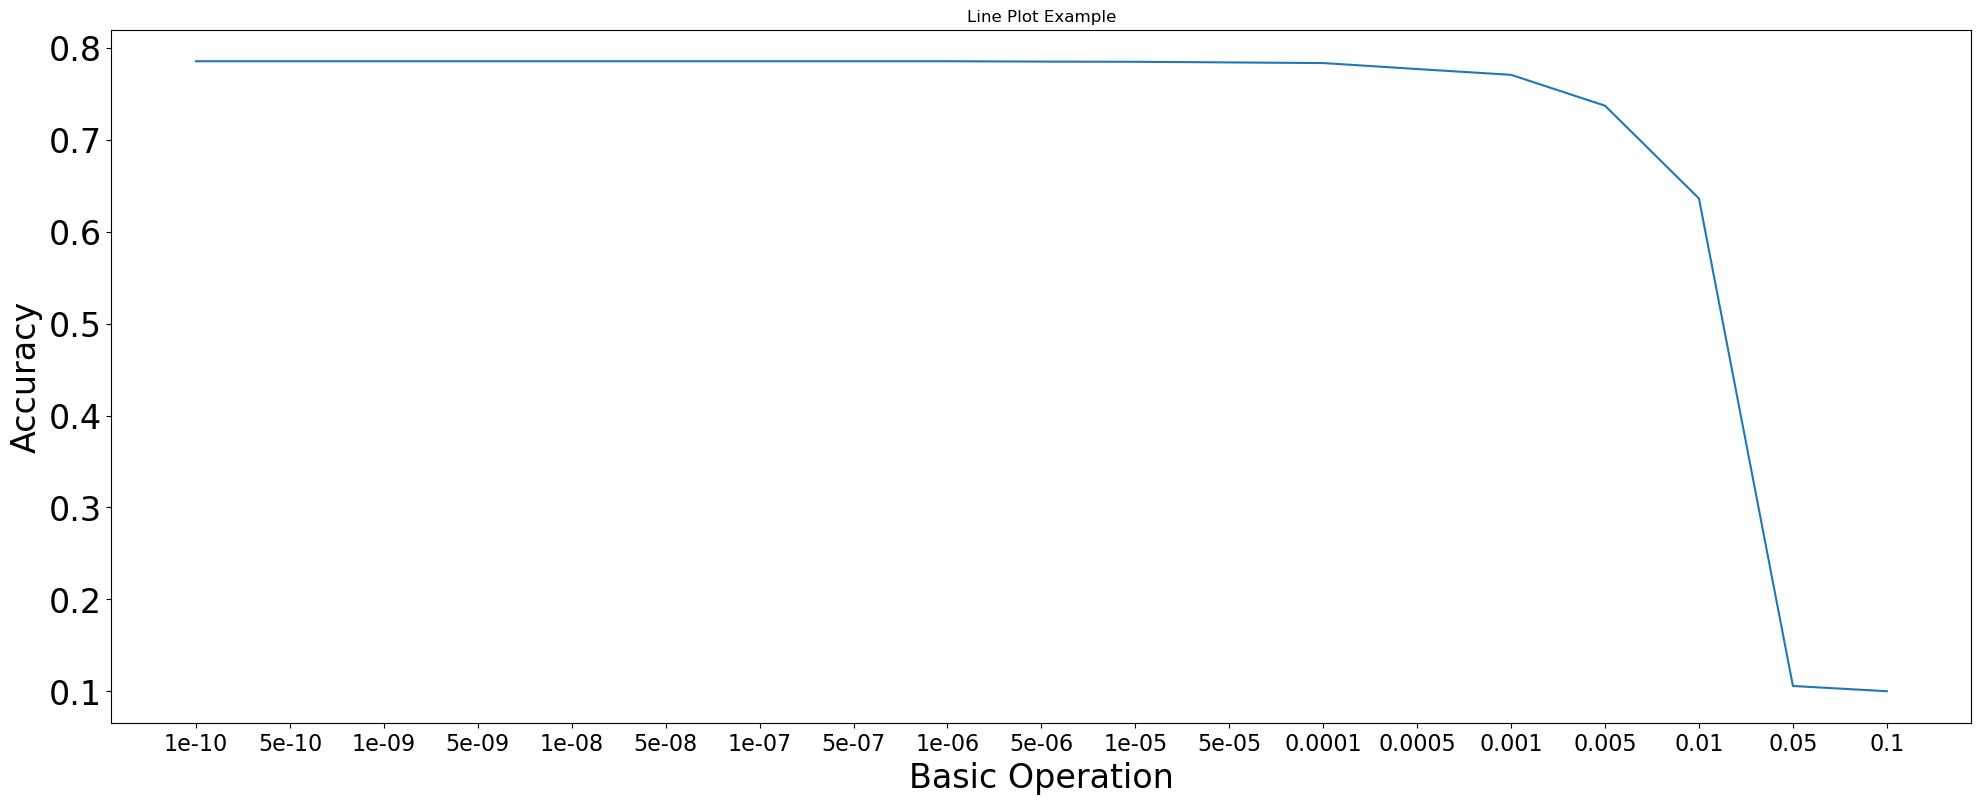

In [10]:
import matplotlib.pyplot as plt
import numpy as np
prob_list = [1e-10, 5e-10, 1e-9,5e-9,1e-8,5e-8,1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2,1e-1]

acc_list = [0.7854,0.7854,0.7854,0.7854,0.7854,0.7854,0.7854,0.7854,0.7854,0.7850,0.7848,0.7841,0.7834,0.7769,0.7706,0.7370,0.6361,0.1058,0.1001]

x = np.linspace(0,19,19)
string_prob_list = [str(num) for num in prob_list]

plt.figure(figsize=(24,9),facecolor='white')
# Plotting the line
plt.plot(x, acc_list)

# Adding labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Line Plot Example')
plt.yticks(fontsize=24)
plt.xticks(x,string_prob_list,fontsize = 16)
plt.ylabel("Accuracy",fontsize = 24)
plt.xlabel("Basic Operation",fontsize = 24)
# Display the plot
plt.show()

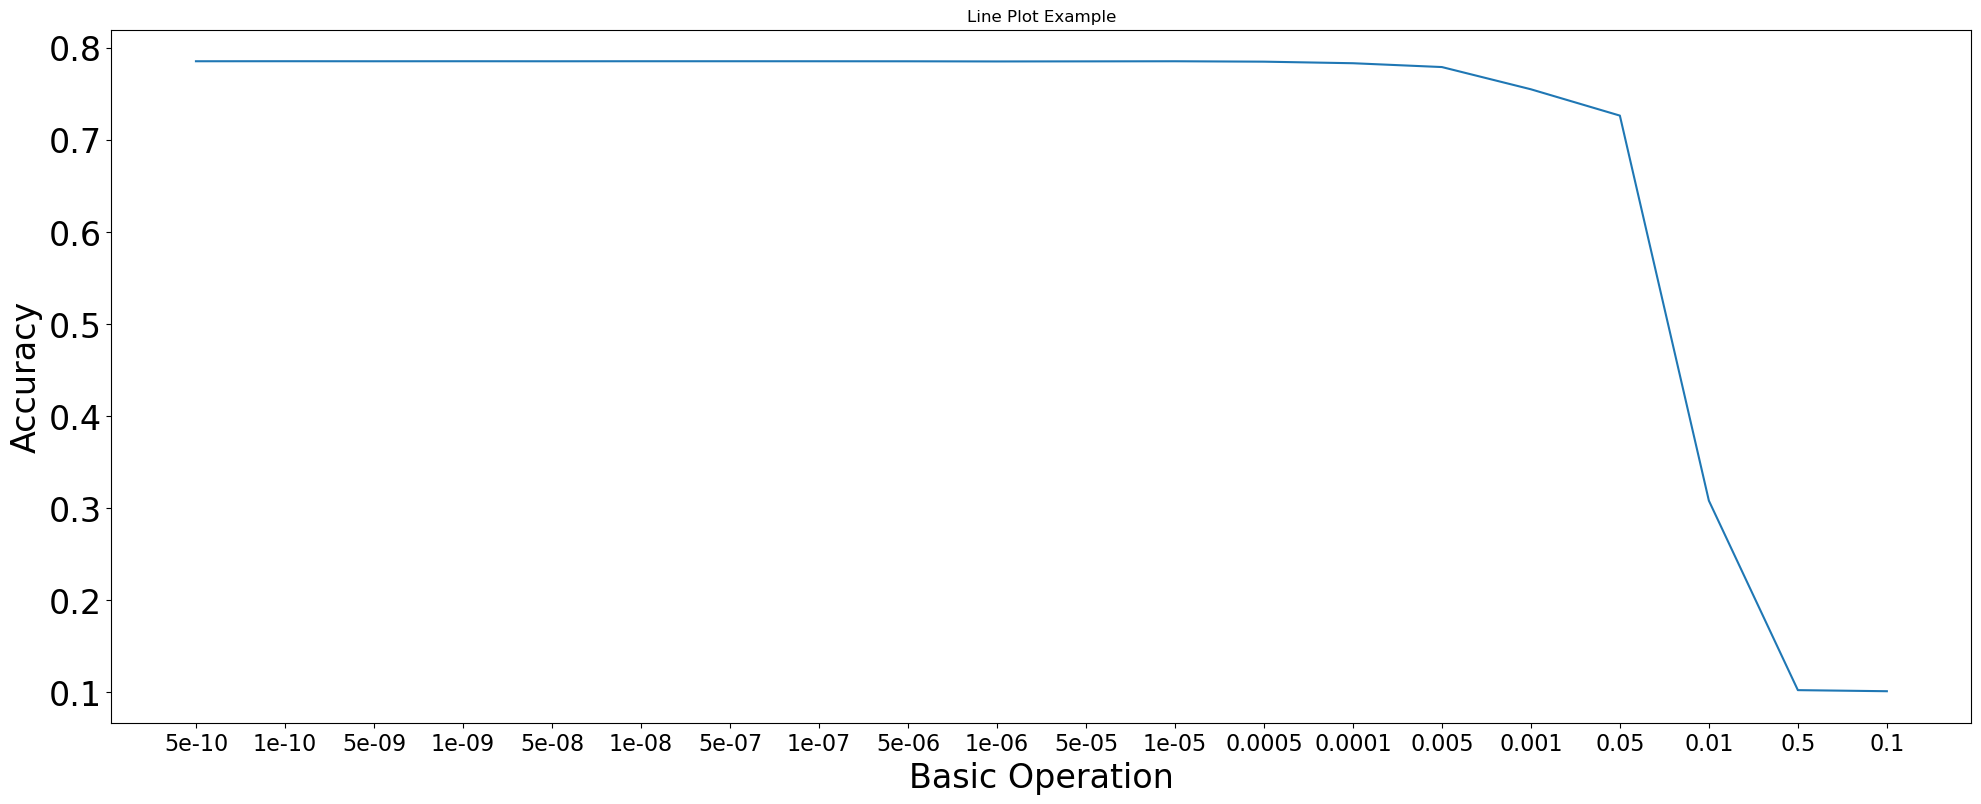

In [12]:
import matplotlib.pyplot as plt
import numpy as np
prob_list = [5e-10, 1e-10, 5e-9,1e-9, 5e-8, 1e-8, 5e-7, 1e-7, 5e-6, 1e-6, 5e-5, 1e-5, 5e-4, 1e-4, 5e-3, 1e-3, 5e-2, 1e-2, 5e-1, 1e-1]

acc_list = [0.78539, 0.78542, 0.7853700000000001, 0.7854, 0.7853600000000001, 0.7854, 0.7854, 0.78538, 0.78534, 0.7851699999999999, 0.78526, 0.7853800000000001, 0.78494, 
            0.7832399999999999, 0.7790900000000001, 0.7549499999999999, 0.7263599999999999, 0.3082, 0.10242, 0.10124]

x = np.linspace(0,20,20)
string_prob_list = [str(num) for num in prob_list]

plt.figure(figsize=(24,9),facecolor='white')
# Plotting the line
plt.plot(x, acc_list)

# Adding labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Line Plot Example')
plt.yticks(fontsize=24)
plt.xticks(x,string_prob_list,fontsize = 16)
plt.ylabel("Accuracy",fontsize = 24)
plt.xlabel("Basic Operation",fontsize = 24)
# Display the plot
plt.show()